# Notebook 01 – Data Cleaning & Imputation
This notebook loads the UCI Heart Disease dataset, applies rigorous cleaning, and imputes missing values using MICE (Iterative Imputer).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

from src.data_prep import load_data, clean_data, impute_missing_values, generate_synthetic_data

sns.set_theme(style='whitegrid', palette='muted')
print("Libraries loaded ✓")


Libraries loaded ✓


## 1. Load Data

In [2]:
# Try loading real UCI data; fall back to synthetic for demonstration
DATA_PATH = '../data/raw/heart_disease.csv'

if os.path.exists(DATA_PATH):
    df_raw = load_data(DATA_PATH)
    print(f"Loaded real data: {df_raw.shape}")
else:
    df_raw = generate_synthetic_data(n=303, random_state=42)
    print(f"Using synthetic data: {df_raw.shape}")

df_raw.head()


Using synthetic data: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,37,0,0,146,197,1,1,182,0,0.5,2,0.0,3.0,0
1,55,0,1,130,334,1,1,171,0,0.3,2,3.0,3.0,0
2,59,0,2,126,246,1,1,127,1,4.9,0,1.0,2.0,1
3,46,1,0,105,212,1,0,153,0,0.2,0,0.0,1.0,0
4,41,0,0,123,174,1,0,119,0,1.6,2,1.0,3.0,1


In [3]:
print("Shape:", df_raw.shape)
print("\nDtypes:\n", df_raw.dtypes)
print("\nMissing values:\n", df_raw.isnull().sum())


Shape: (303, 14)

Dtypes:
 age           int32
sex           int64
cp            int64
trestbps      int32
chol          int32
fbs           int64
restecg       int64
thalach       int32
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
target        int32
dtype: object

Missing values:
 age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca          15
thal        15
target       0
dtype: int64


## 2. Visualise Missingness

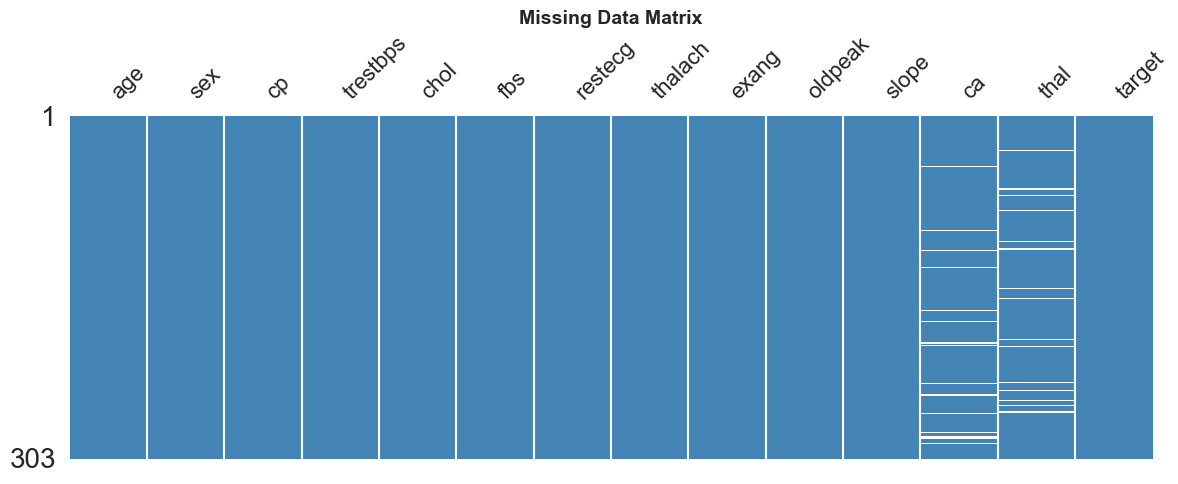

Missingness pattern saved.


In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
msno.matrix(df_raw, ax=ax, color=(0.27, 0.52, 0.71), sparkline=False)
ax.set_title("Missing Data Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/missing_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Missingness pattern saved.")


## 3. Clean Data

In [5]:
df_clean = clean_data(df_raw)
print("After cleaning:", df_clean.shape)
print("Duplicates removed:", df_raw.shape[0] - df_clean.shape[0])
print("Missing values remaining:\n", df_clean.isnull().sum())


After cleaning: (303, 14)
Duplicates removed: 0
Missing values remaining:
 age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca          15
thal        15
target       0
dtype: int64


## 4. Outlier Detection – IQR Boxplots

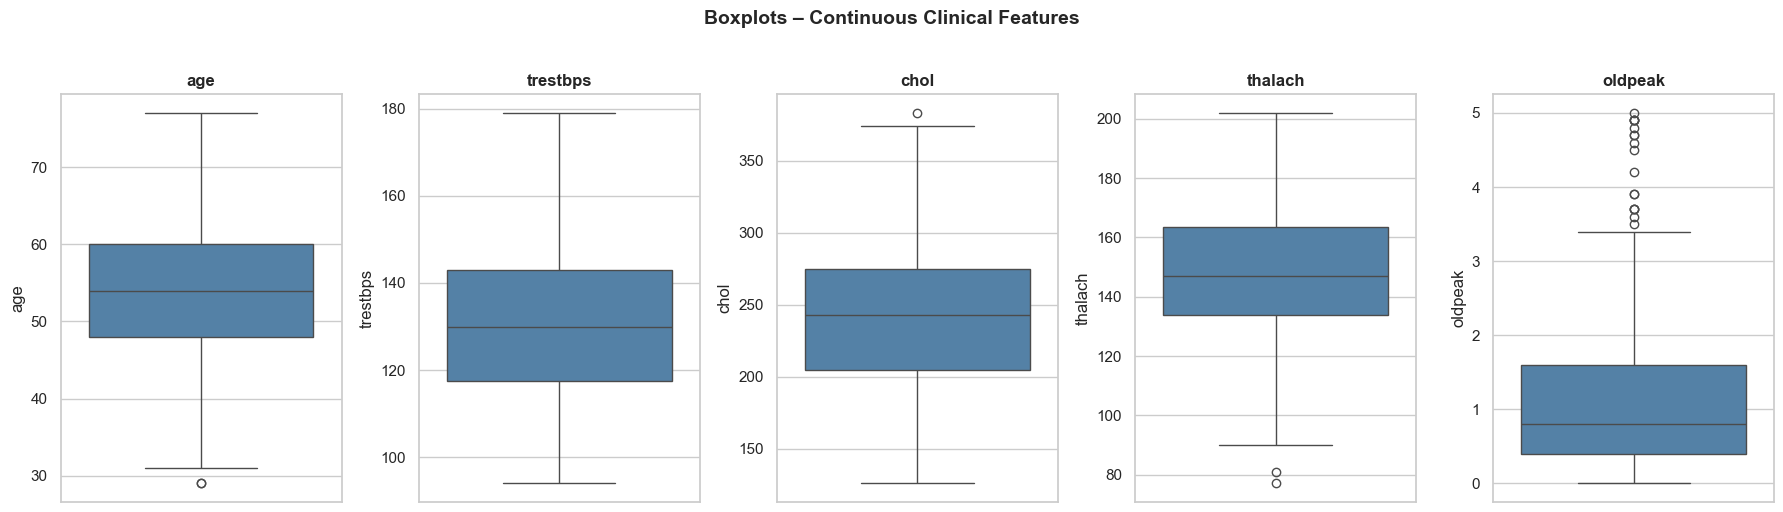

In [6]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 5))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df_clean[col], ax=ax, color='steelblue')
    ax.set_title(col, fontweight='bold')
plt.suptitle('Boxplots – Continuous Clinical Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Advanced Imputation (MICE – IterativeImputer)

In [7]:
df_imputed = impute_missing_values(df_clean, strategy='mice')
print("After MICE imputation:", df_imputed.shape)
print("NaN values remaining:", df_imputed.isnull().sum().sum())
assert df_imputed.isnull().sum().sum() == 0, "Imputation failed!"
print("✅ No missing values – imputation successful.")


After MICE imputation: (303, 14)
NaN values remaining: 0
✅ No missing values – imputation successful.


In [8]:
os.makedirs('../data/processed', exist_ok=True)
df_imputed.to_csv('../data/processed/heart_clean.csv', index=False)
print("Cleaned & imputed dataset saved to data/processed/heart_clean.csv")
df_imputed.describe().round(2)


Cleaned & imputed dataset saved to data/processed/heart_clean.csv


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.0
mean,54.04,0.49,1.47,129.78,240.56,0.48,0.90,147.82,0.45,1.20,0.97,1.54,2.02,0.5
std,8.69,0.50,1.17,18.27,52.21,0.50,0.83,23.72,0.50,1.14,0.80,1.08,0.79,0.5
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,77.00,0.00,0.00,0.00,0.00,1.00,0.0
25%,48.00,0.00,0.00,117.50,205.00,0.00,0.00,134.00,0.00,0.40,0.00,1.00,1.00,0.0
50%,54.00,0.00,2.00,130.00,243.00,0.00,1.00,147.00,0.00,0.80,1.00,1.45,2.00,0.0
75%,60.00,1.00,3.00,143.00,275.00,1.00,2.00,163.50,1.00,1.60,2.00,3.00,3.00,1.0
max,77.00,1.00,3.00,179.00,383.00,1.00,2.00,202.00,1.00,5.00,2.00,3.00,3.00,1.0
